<a href="https://colab.research.google.com/github/ancantos99/proyectointegrador_ia_grupo8/blob/main/notebooks%20/03_modelado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 🖥️ Proyecto: Detección de Cambios en Interfaces Web para RPA usando IA
***

# 🏗️ Modelado y Diagnóstico de Overfitting/Underfitting con YOLOV8 en un Dataset de elementos de interfaz de usuario WEB

***

## 👨‍🔬 Autores

* **Paola Mendoza**
* **Andrés Cantos**

---
## 📝 Introducción y Objetivos del Análisis

Este cuaderno de Colab tiene como objetivo principal realizar un **análisis detallado del proceso de entrenamiento** del modelo **YOLOv8** (You Only Look Once, versión 8) utilizando un **conjunto de datos de elementos de la interfaz de usuario web**.

Los objetivos específicos son:

1.  **Entrenar un Modelo Base:** Configurar y ejecutar un entrenamiento inicial de YOLOv8 para establecer un punto de referencia.
2.  **Analizar Overfitting/Underfitting:** Monitorear y evaluar las curvas de entrenamiento (pérdida, precisión) en los conjuntos de entrenamiento y validación para identificar si el modelo está sufriendo de **sobreajuste (overfitting)** o **subajuste (underfitting)**.
3.  **Implementar Tracking y Logging:** Establecer un sistema robusto de seguimiento para registrar de forma persistente:
    * Métricas clave (mAP, F1-Score).
    * Curvas de aprendizaje.

---
## 1️⃣ **Carga y Exploración del Dataset**

### 1.1 Descripción del Dataset: UI Elements Detection Dataset

- **Explicación**

  Para este análisis, utilizaremos el **"UI Elements Detection Dataset"** de Hugging Face.

  * **Fuente:** [YashJain/UI-Elements-Detection-Dataset](https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset)
  * **Contenido:** Imágenes de interfaces de usuario web con anotaciones de objetos (Bounding Boxes) para la detección de elementos comunes de UI (botones, barras de búsqueda, texto, etc.).
  * Anotaciones o labels en formato **YOLO**: **class_id xcenter ycenter ancho alto**
  * **Formato de Anotación:** Las coordenadas de los *bounding boxes* están
  **normalizadas** (valores entre 0 y 1)
  * **¿Cómo Obtenerlo?:** clonar el repositorio de huggin face con git clone y ubicarlo en /content/dataset

- **Modularidad o Reusabilidad**

  Para analizar el dataset se creó la Clase **YOLODatasetManager**

  Esta clase se encuentra en el archivo [tools/YOLODatasetManager.py](/tools/YOLODatasetManager.py) y contiene varios métodos para manipular el dataset y el archivo de configuración dataset.yaml

### 1.2 Objetivos de la Exploración

1.  Identificar la lista completa de **clases disponibles** para la detección.
2.  Analizar la **distribución de frecuencias** de las anotaciones para detectar desbalance.

La exploración del dataset será YOLODatasetManager


In [ ]:
# Clonar el repo del dataset en /content/dataset
!git lfs install > /dev/null 2>&1
!git clone https://huggingface.co/datasets/YashJain/UI-Elements-Detection-Dataset /content/dataset > /dev/null 2>&1
print("✅ Git LFS instalado y el dataset clonado en '/content/dataset' de forma silenciosa.")

✅ Git LFS instalado y el dataset clonado en '/content/dataset' de forma silenciosa.


In [ ]:
#Instarlar librerias
!pip install ultralytics > /dev/null 2>&1
print("✅ Ultralytics instalado de forma silenciosa")

✅ Ultralytics instalado de forma silenciosa


In [ ]:
#Descargo librerias propias
import os
os.makedirs("/content/tools", exist_ok=True)
!wget -q https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/tools/YOLODatasetManager.py -O /content/tools/YOLODatasetManager.py
!wget -q https://raw.githubusercontent.com/ancantos99/proyectointegrador_ia_grupo8/refs/heads/main/src/tools/YOLOMetricasVisualizar.py -O /content/tools/YOLOMetricasVisualizar.py
import importlib
import logging
import sys
sys.path.append("/content/tools")
import YOLODatasetManager
import YOLOMetricasVisualizar
#Recarga de archivos - Para actualizar al último Push
importlib.reload(YOLODatasetManager)
importlib.reload(YOLOMetricasVisualizar)
from YOLODatasetManager import YOLODatasetManager
from YOLOMetricasVisualizar import YOLOMetricasVisualizar
# Configuración global del Login
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', force=True )

Distribución: {'0': 15583, '1': 5101, '2': 354, '3': 0, '4': 26, '5': 1032, '6': 42, '7': 54, '8': 799, '9': 15, '10': 8, '11': 820, '12': 23, '13': 141, '14': 0, '15': 0}


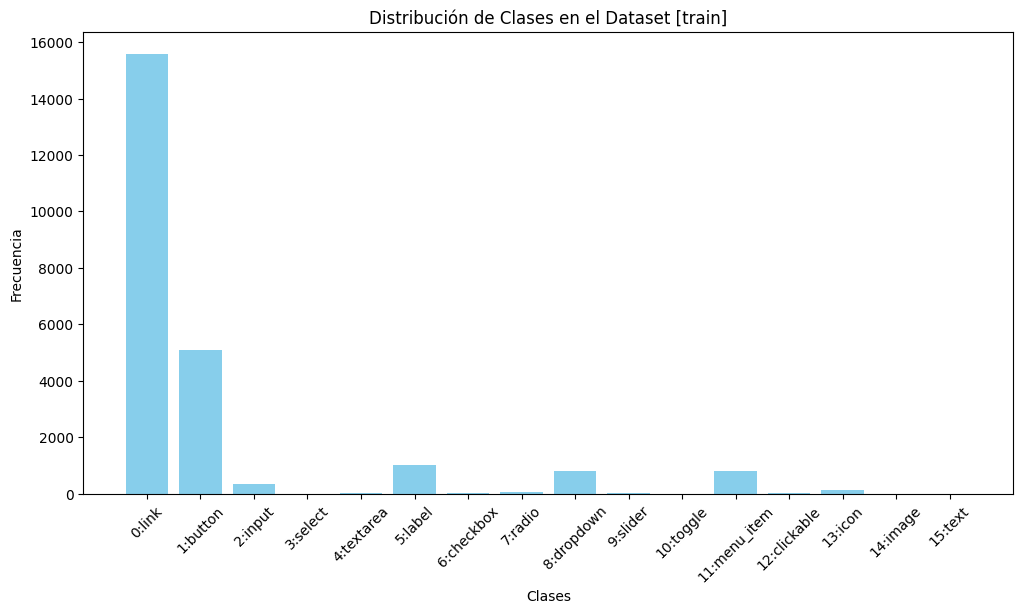

In [ ]:
datasetmanager = YOLODatasetManager("/content/dataset")
counts = datasetmanager.compute_class_distribution("train")
print("Distribución:", counts)
datasetmanager.plot_distribution()

## 1.3 Análisis de la Distribución de Clases del Dataset de entrenamiento YOLO

- **Desequilibrio de clases muy fuerte**
  - La clase '0-Link' domina con 15583 ejemplos
  - Muchas clases tienen menos de 1000 ejemplos, e incluso algunas menos de 50
  - Algunas clases '3-select','14-image', '15-text' no tienen ejemplos

- **Clases minoritarias casi invisibles**
  - Clases minoritarias casi invisibles:  '2' (354), '4' (26), '12' (23) tienen muy pocos ejemplos
  - El modelo podría no aprender estas clases correctamente, tendiendo a predecir solo las clases más frecuentes

- **Posibles Acciones**
  - Sobremuestreo de clases minoritarias
  - Aplicar data augmentation en clases con pocos ejemplos
  - Eliminar las clases sin representación del archivo dataset.yaml

El dataset está muy desbalanceado y tiene clases sin representación.

Si se entrena un modelo YOLO con estos datos, probablemente prediga casi siempre la clase '0' y fallará en detectar las clases minoritarias

Es prioritario aplicar técnicas de balanceo o ajuste de pérdida antes de entrenar para obtener un modelo más robusto y equitativo.




In [ ]:
#datasetmanager.yaml_eliminar_clases([3, 14, 15]);

In [ ]:
datasetmanager.aplicar_sobremuestreo("train",cantidad_seleccion_minoritaria=2000)

2025-10-01 02:04:38,392 - YOLODatasetManager - INFO - Distribución original: {'0': 15583, '1': 5101, '2': 354, '3': 0, '4': 26, '5': 1032, '6': 42, '7': 54, '8': 799, '9': 15, '10': 8, '11': 820, '12': 23, '13': 141, '14': 0, '15': 0}
2025-10-01 02:04:38,787 - YOLODatasetManager - INFO - Cantidad de clase dominante: 15583
2025-10-01 02:07:35,588 - YOLODatasetManager - INFO - Dataset balanceado con SobreMuestreo y guardado en: /content/dataset/train_balanced


In [ ]:
#Eliminar carpeta
#!rm -rf /content/dataset/train_balanced

Distribución del Dataset Balanceado con sobremuestreo: {'0': 1710213, '1': 540947, '2': 55038, '3': 0, '4': 15574, '5': 111398, '6': 15582, '7': 19867, '8': 60626, '9': 15570, '10': 15576, '11': 72790, '12': 18098, '13': 35697, '14': 0, '15': 0}


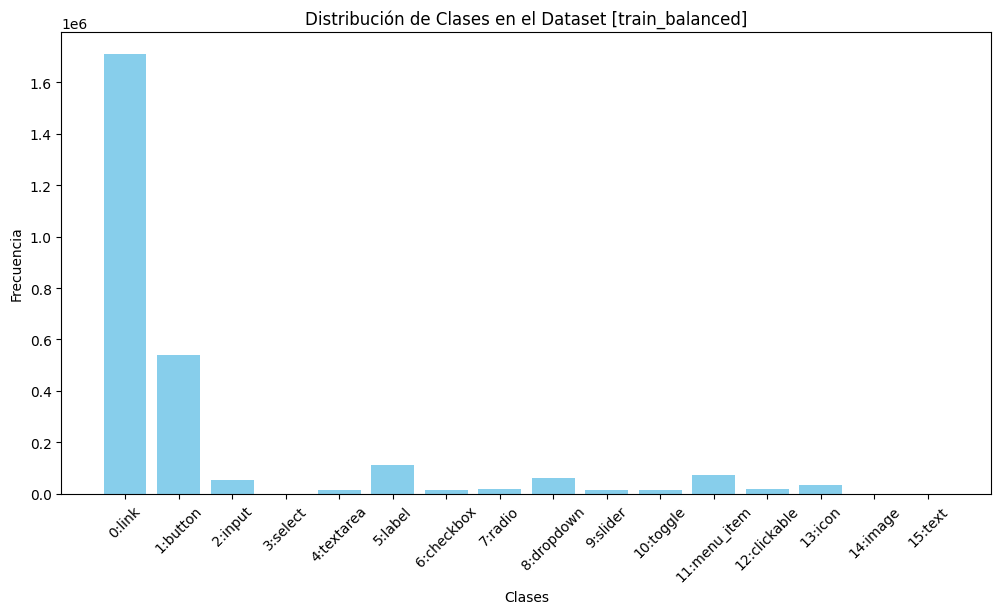

In [ ]:
counts = datasetmanager.compute_class_distribution("train_balanced")
print("Distribución del Dataset Balanceado con sobremuestreo:", counts)
datasetmanager.plot_distribution()

## 🔎 1.4 Observaciones del Sobremuestreo del Dataset

Al analizar el proceso de sobremuestreo aplicado al dataset YOLO, se observó lo siguiente:

- La estrategia actual consiste en duplicar imágenes que contienen clases minoritarias, con el objetivo de equilibrar la distribución de clases.
- Sin embargo, muchas de estas imágenes no solo contienen las clases minoritarias, sino también clases de alta frecuencia (clases dominantes).
- Como resultado, al duplicar estas imágenes, **no solo aumentan las clases minoritarias**, sino también las clases ya abundantes.
- Esto provoca que el sobremuestreo termine **incrementando la frecuencia de todas las clases**, lo que reduce la efectividad del balanceo y no corrige correctamente el desbalance original del dataset.
- El sobremuestreo genera una gran cantidad de datos adicionales, lo que **incrementa significativamente la demanda de memoria y cómputo durante el entrenamiento**. Como consecuencia, el entrenamiento se vuelve más costoso y puede llegar a fallar por falta de recursos.
- Además, se observa que **las páginas tienen más links por naturaleza y menos botones**, lo que explica por qué el dataset presenta esta distribución de clases: los links son intrínsecamente más frecuentes que botones o inputs.

Esta observación sugiere que el simple sobremuestreo de imágenes completas **no es suficiente para datasets multiclase donde las imágenes contienen varias clases**, y que el desbalance también refleja un sesgo natural de los elementos en las páginas web.

---

## 2️⃣ **Implementación del Sistema de Tracking**

- **Explicación:**

  Se va a usar los **logs nativos de YOLOv8 (results.csv)** como sistema de tracking, básicamente se va a monitorear las métricas de entrenamiento y evaluación directamente desde los archivos generados por YOLOv8, sin necesidad de herramientas externas.

- **Modularidad o Reusabilidad**

  Para analizar este archivo results.csv se creará una Clase **YOLOMetricasVisualizar** en un archivo py del mismo nombre

### 2.1 Configuración del Sistema de Tracking usando Logs Nativos de YOLOv8

#### Objetivos

Registrar y monitorear el desempeño del modelo durante el entrenamiento y validación, esto incluye métricas claves como:
- precision
- recall
- F1 - Score
- Métricas por Clase
- Curvas de Training Vs Validation Loss
- Curvas Validation Accuracy mAP

Toda la información necesaria para calcular estas métricas, se guarda automáticamente en **results.csv** por YOLOv8

### 2.2 Configuración del Tracking

- **Ubicación de los logs:**

  Cada entrenamiento de YOLOv8 genera un folder **runs/(nombre del run)** que contiene:
    - results.csv → métricas por epoch
    - train_batch0.jpg, val_batch0.jpg, … → ejemplos de predicción
    - events.out.tfevents.* → si TensorBoard está habilitado

- **Habilitación de logs:**

  Por defecto, **YOLOv8 guarda results.csv en cada ejecución** de model.train().
  
  Se puede configurar el nombre de la carpeta (nombre del run) y ubicación.

  Ejemplo:
    
  ```
  from ultralytics import YOLO
  model = YOLO("yolov8n.pt")
  model.train(
      data="data.yaml",
      epochs=50,
      imgsz=640,
      batch=16,
      name="experiment_01",   # nombre del run
      exist_ok=True,          # sobrescribe si ya existe
      project="/content/runs" # ruta de la carpeta runs
  )
  ```
### 2.3 Formato de results.csv:

- Cada fila corresponde a un epoch del entrenamiento.

- Columnas típicas:
  - epoch → número de epoch
  - time
  - train/box_loss → pérdida de caja en train
  - train/cls_loss → pérdida de clase en train
  - train/dfl_loss
  - metrics/precision(B) → precisión global
  - metrics/recall(B) → recall global
  - metrics/mAP50(B)
  - metrics/mAP50-95(B)
  - val/box_loss → pérdida de caja en val
  - val/cls_loss → pérdida de clase en train
  - val/dfl_loss

### 2.4 Ventajas de usar results.csv

- No requiere herramientas externas, ideal para Colab o entornos aislados.
- Permite **analizar evolución de métricas**, generar gráficos y comparar distintos entrenamientos.
- Compatible con **Python/pandas/matplotlib** para visualizaciones personalizadas.   


---
## 3️⃣ **Entrenamiento del modelo Base**


In [ ]:
from ultralytics import YOLO
#Entrenar YOLO de manera clásica con el dataset train, para eso modifico la ruta en el dataset.yaml
datasetmanager.yaml_cambiar_carpeta(split="train",nuevaruta="train")
model = YOLO("yolov8n.pt")  # "Version Nano" o yolov8s.pt, yolov8m.pt según prefieras small, medium, etc.
# Cargar dataset usando YOLOv8 Dataset
carpeta_salida = "exp_n_data" #carpeta donde se van a guardar los resultados del entrenamiento de YOLO y el modelo
model.train(data=datasetmanager.ruta_yaml,
    epochs=116, #epocas
    imgsz=640, #tamaño a los que se redimensionara la imagen de entrada
    batch=16,  #tamaño del batch (ajustarlo según Vram)
    name= carpeta_salida,   # nombre del run
    exist_ok=True,          # sobrescribe si ya existe
    project="/content/runs" # ruta de la carpeta runs
)

---
## 4️⃣ **Generación de todas las curvas requeridas**

Para generar todos los gráficos se crearon diferentes métodos en la clase YOLOMetricasVisualizar.

- Esta clase se encuentra en el archivo [tools/YOLOMetricasVisualizar.py](/tools/YOLOMetricasVisualizar.py)
- El constructor de la clase recibe la ruta del archivo results.csv generado durante el entrenamiento de YOLOv8, este archivo contiene todas las métricas por época. Además recibe de manera opcional el modelo .pt y la ruta del archivo de configuración datasetmanager.yaml para evaluar las métricas del modelo por cada clase.


In [ ]:
# Crear objeto Visualizador
visualizer = YOLOMetricasVisualizar(f"/content/runs/{carpeta_salida}/results.csv",
                                    f"/content/runs/{carpeta_salida}/weights/best.pt",datasetmanager.ruta_yaml)

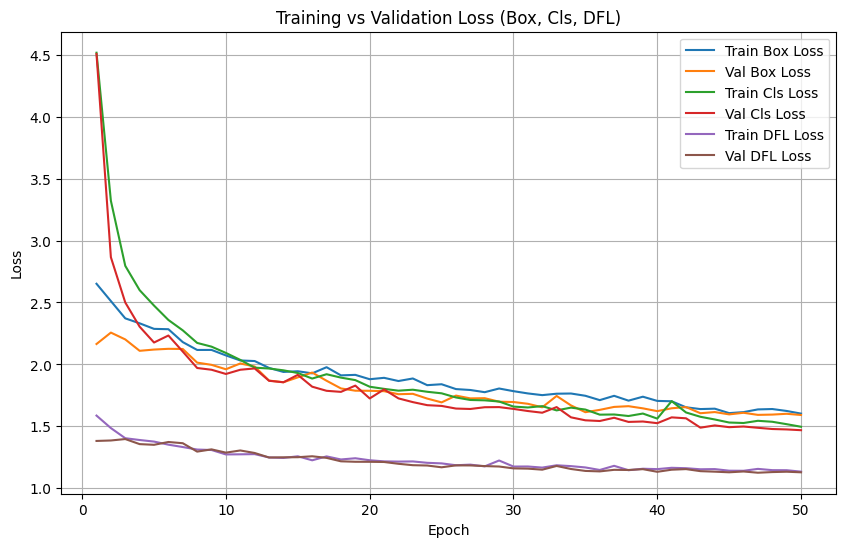

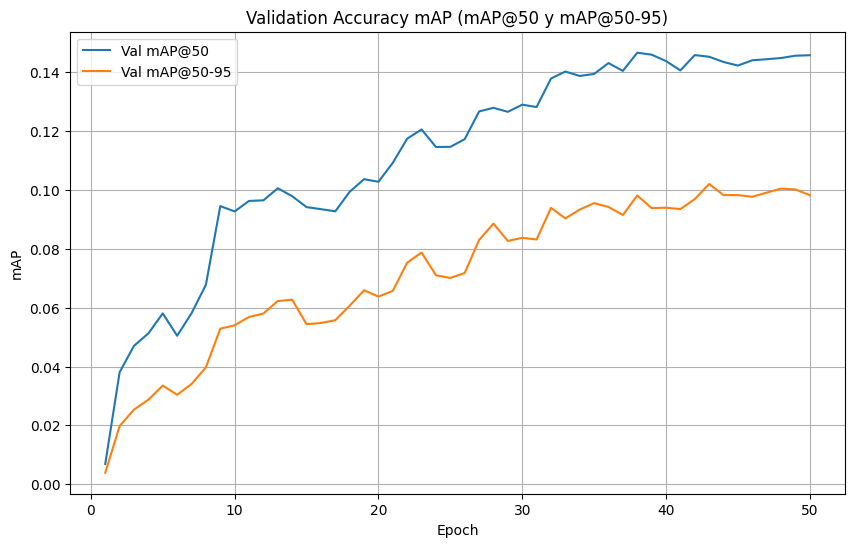

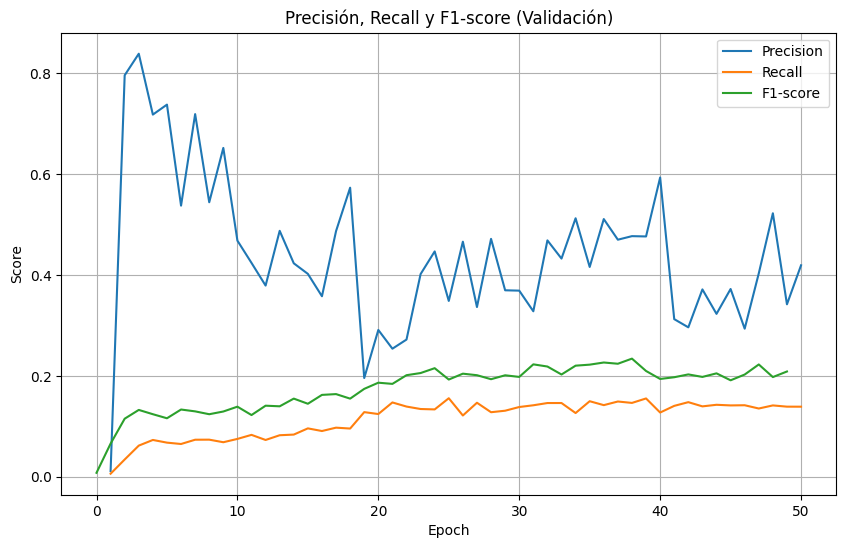

Final Metrics (last epoch):
Precision: 0.4194
Recall:    0.1391
F1-score:  0.2089


,Clase,Precision,Recall,F1,mAP50
0,link,0.452187,0.381417,0.413797,0.337599
1,button,0.474162,0.41297,0.441456,0.398965
2,input,0.581204,0.425926,0.491595,0.401312
3,select,clase sin métricas,clase sin métricas,clase sin métricas,clase sin métricas
4,textarea,0.723185,0.25,0.371556,0.26117
5,label,0.541964,0.016949,0.03287,0.030227
6,checkbox,clase sin métricas,clase sin métricas,clase sin métricas,clase sin métricas
7,radio,0.0,0.0,0.0,0.0
8,dropdown,0.328571,0.050633,0.087744,0.08174
9,slider,0.0,0.0,0.0,0.0


In [ ]:
visualizer.plot_loss() # Graficar Loss
visualizer.gap_entretrainyval() # Graficar Gap
visualizer.plot_map()  # Graficar mAP
visualizer.plot_precision_recall_f1() # Graficar Precision, Recall, F1
visualizer.print_final_metrics() # Mostrar métricas finales
#Metricas por Clase
df = visualizer.metrics_por_clase_tabla()   # Imprime Precision, Recall, F1 y mAP50 por clase
display(df)

---
## 5️⃣ **Análisis y diagnóstico detallado**

Los resultados mostraron que el modelo YOLOv8m logró un incremento en precisión respecto a la versión nano, pero el recall sigue siendo bajo. El dataset presenta fuerte desbalance y falta de ejemplos en varias clases.

- El mejor Entrenamiento base obtuvo:
  - Precision: 0.6155
  - Recall:    0.1969
  - F1-score:  0.2983
- Métricas por Clase:
Las mejores métricas se obtuvo en las clases '0-link', '1-button', '2-input'
  - '0-link' → Precision: 0.60, recall: 0.46, F1-score: 0.52
  - '1-button' → Precision: 0.60, recall: 0.46, F1-score: 0.52
  - '2-input' → Precision: 0.76, recall: 0.59, F1-score: 0.67

### 5.1 Diagnóstico Sistematizado

- **Identificación de Patrones**
  - Overfitting: No se evidencian síntomas graves; no hay gap grande reportado entre train/val.
  - Underfitting: Sí presente; métricas bajas y muchas clases sin aprendizaje.
  - Comportamiento óptimo: Se observa parcialmente en clases frecuentes como link, button e input.
    - Tanto train loss como val loss permanecieron en valores relativamente altos.
    - La precisión fue baja y el recall casi nulo (0.19), evidenciando que el modelo no logra aprender patrones representativos del dataset.

- **Análisis Cuantitativo**
  - mAP50 promedio entre 0.35 y 0.40 en YOLOv8n; hasta 0.62 en YOLOv8m.
  - Más del 40% de clases no aprendidas (métricas 0).
  - Recall global < 0.20 en la mayoría de pruebas.

### 5.2 Estrategias de Mejora Propuestas

- **Recomendaciones Específicas para Underfitting**
  1.   Aumentar tamaño y calidad del dataset (más imágenes y anotaciones de clases minoritarias).
  2.   Data augmentation más variada (rotaciones, contraste, recortes, blur).
  3.   Usar modelos más complejos (YOLOv8m/l).
  4.   Ajustar hiperparámetros: learning rate más dinámico, más épocas.
  5.   Pérdida focal (focal loss) para clases desbalanceadas.

### 5.3 Conclusiones del análisis

El bajo recall y desempeño desigual entre clases indica underfitting asociado a datos insuficientes y desbalance. Se recomienda priorizar un prototipo inicial enfocado en las clases input, button y link, combinando aumento de datos y un modelo más robusto (YOLOv8m/l con focal loss).


---
## 6️⃣ **Implementación de Estrategias de Mejora**

1. **Entrenar con un modelo más robusto (YOLOv8l) + focal loss:**

- La versión m ya mostró mejores resultados.
- Ajustar hiperparámetros: learning rate más dinámico, más épocas.
- focal loss puede mejorar la detección de clases minoritarias reduciendo el sesgo hacia clases frecuentes.

2. **Data augmentation más variada (rotaciones, contraste, recortes, blur).**
- YOLOv8 permite aplicar augmentations automáticamente durante el entrenamiento usando parámetros como augment=True:

### 6.1 Cambios en la implementación o entrenamiento (Ajustar Hiperparámetros)

Para incluir (learning rate dinámico, focal loss, Data augmentation), YOLOv8 permite pasar un archivo de hiperparámetros en el entrenamiento.
  
A continuación se mencionan El modelo y los hiperparámetros a modificar:

1. **Entrenar con un modelo más robusto**
    - Se usará YOLOV8l, la versión large de YOLOv8, cuenta con 43.7 millones de parámetros. Es un poco más precisa pero también más lenta y consume más recursos de memoria y cómputo

2. **Entrenamiento básico**
    - **epochs=200** → Número de épocas que entrenará el modelo. Se elige alto para que el modelo pueda aprender los detalles finos de las clases minoritarias (ej. botones o inputs poco frecuentes).
    - **imgsz=640** → Tamaño al que se redimensionarán todas las imágenes. Para UI, mantiene suficiente resolución para que los elementos pequeños (iconos, sliders) sigan siendo detectables.
    - **batch=16** → Cantidad de imágenes procesadas por iteración. Ajustable según memoria VRAM de la GPU.
    - **name=carpeta_salida** → Nombre del experimento/run.
    - **exist_ok=True** → Permite sobrescribir resultados previos en la misma carpeta.
    - **project="/content/runs"** → Carpeta donde se guardan todos los resultados y modelos entrenados.

3.  **Data augmentation y robustez:**
    - **augment=True** → Activa augmentations, pero en este caso solo se usan los seguros para UI (colores, brillo).
    - **cos_lr=True** → Usa un scheduler de learning rate en forma de coseno. Esto permite que el LR baje lentamente al final, ayudando a aprender detalles de clases minoritarias.

4. **Learning rate y optimización:**
    - **lr0=0.01** → Learning rate inicial. Controla qué tan rápido aprende el modelo.
    - **lrf=0.01** → Factor de reducción final del LR; al final del entrenamiento, LR final = lr0 * lrf. Ayuda a afinar los detalles sin sobreajustar.
    - **momentum=0.937** → Factor de “inercia” para el optimizador SGD, suaviza los pasos de actualización.
    - **weight_decay=0.0005** → Regularización para evitar sobreajuste.
    - **warmup_epochs=3.0** → Número de épocas de “calentamiento” donde el LR sube gradualmente al inicial.
    - **warmup_momentum=0.8** → Momentum inicial durante warmup.
    - **warmup_bias_lr=0.1** → LR inicial para los sesgos durante warmup.
  
  - **¿Por qué elegimos lr0 y lrf = 0.01 para interfaces web?**
  
    - El dataset tiene clases muy desbalanceadas

    - Un LR final más bajo ayuda a que el modelo ajuste detalles finos de las clases minoritarias al final del entrenamiento, sin sobrepasarse en las clases dominantes

    - como además estamos usando cos_lr=True (decay coseno), el LR empieza alto para aprender rápido y luego disminuye suavemente

5. **Loss (función de pérdida):**

    La idea es priorizar precisión en ubicación y forma (box y dfl) mientras se mantiene suficiente atención a la clasificación (cls) para distinguir tipos de elementos.

    - **box=7.5** → Peso de la pérdida de las cajas delimitadoras (bounding boxes). Aumenta la importancia de ajustar bien la posición y tamaño de las cajas delimitadoras, crítico para UI donde los elementos son pequeños y cercanos.
    - **cls=0.5** → Peso de la pérdida de clasificación. Menor peso en la clasificación. Se prioriza la posición exacta de los elementos (ya que en UI es más crítico que estén bien localizados elementos como botón, link, input).
    - **dfl=1.5** → Distribución de bounding boxes; ayuda a refinar la precisión de tamaño y forma, útil para interfaces donde los elementos tienen proporciones específicas (inputs, botones, sliders).

6. **Data augmentation seguro para interfaces web:**

    En datasets de interfaces web, no conviene usar augmentations que alteren la geometría

    - **hsv_h=0.015, hsv_s=0.7, hsv_v=0.4** → Ajustes de color, saturación y brillo para simular variaciones de tema o pantalla.
    - **degrees=0.0, translate=0.0, scale=0.0, shear=0.0** → No se alteran posiciones ni orientación de elementos; esencial para mantener la estructura del layout.
    - **flipud=0.0, fliplr=0.0** → No se hacen flips; los elementos no pueden invertirse.
    - **mosaic=0.0** → No se combinan varias imágenes, para no romper la coherencia de la UI.
    - **mixup=0.0** → No se mezclan imágenes; cada screenshot conserva su estructura.

**Resumen**

La configuración está pensada para preservar la estructura exacta de la interfaz web, mientras se usan solo augmentations de color/contraste que ayudan a la generalización. Además, se ajustan parámetros de LR y pérdida para clases desbalanceadas y detalles finos en elementos UI pequeños.

### 6.2 Tunning de Hiperparámetros

- Métricas globales previas: recall bajo y precision mejorando con modelos más grandes (Yolov8l) → el modelo reconoce ciertos patrones pero genera ruido.

- **Segundo Ajuste de Entrenamiento (Hiperparámetros)**
  - **Reducir lr0:** lr0 = 0.001 ó 0.0025 (0.01 es relativamente alto para yolov8l con cosine).
  - **Reducir weightings extremos:** bajar box=1.5 (en vez de 7.5) para no incentivar demasiadas cajas.
  - **Épocas: ** reducir a epochs=100 (Se observó que mAP no mejora después de las 100 ep)
  - **Desactivar fuertes cambios de color:** hsv_s=0.15, hsv_v=0.1 (en vez de 0.7/0.4).

- **Tercer Ajuste de Entrenamiento (Hiperparámetros)**
  - **Épocas:** aumentarle a 200, pero **Habilitar patience=15** para detener cuando no mejore val y evitar sobreentrenamiento.
  - **Suavizar más augmentations de color**
  - **Ajustar cls y dfl weights** ligeramente a la baja (p. ej. cls=0.35, dfl=1.0)
  - dejar **warmup_momentum y warmup_bias_lr** en los valores que YOLO les de por defecto. Son útiles en dataset muy grandes y este no es el caso
  - Subir **weight_decay de 0.0005 → 0.0015** ayuda a “suavizar” la cabeza de clasificación, reduciendo falsos positivos y mejorando precision. weight_decay es el hiperparámetro que controla la regularización L2 (penalización sobre los pesos grandes de la red).

- Modificar el dataset y Re-entrenar con sólo las 3 clases (input, button, link) para prototipo si quieres resultados estables rápidos.

In [ ]:
from ultralytics import YOLO
datasetmanager.yaml_cambiar_carpeta(split="train",nuevaruta="train")
model = YOLO("yolov8l.pt")  # "Version Nano" o yolov8s.pt, yolov8m.pt según prefieras small, medium, etc.
# Cargar dataset usando YOLOv8 Dataset
carpeta_salida = "exp_l_data2" #carpeta donde se van a guardar los resultados del entrenamiento de YOLO y el modelo
model.train(data=datasetmanager.ruta_yaml,
    epochs=200, #epocas + early stopping (monitorear val mAP y parar si no mejora 10-15 ep).
    imgsz=640, #tamaño a los que se redimensionara la imagen de entrada
    batch=16,  #tamaño del batch (ajustarlo según Vram)
    name= carpeta_salida,   # nombre del run
    exist_ok=True,          # sobrescribe si ya existe
    project="/content/runs", # ruta de la carpeta runs
    augment=True,  # activa data augmentation
    cos_lr=True,   # scheduler coseno en lugar de lineal
    patience=15, # para no sobreentrenar
    # Learning rate y optimización
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0015,
    warmup_epochs=3.0,
    #warmup_momentum=0.8,
    #warmup_bias_lr=0.1,
    # Loss
    box=1.5,
    cls=0.35,
    dfl=1.0,
    # Data augmentation (seguro para UI)
    hsv_h=0.01,
    hsv_s=0.15,
    hsv_v=0.1,
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0
)

In [ ]:
visualizer_v8l = YOLOMetricasVisualizar(f"/content/runs/{carpeta_salida}/results.csv",
                                        f"/content/runs/{carpeta_salida}/weights/best.pt",datasetmanager.ruta_yaml)

### **Gráficos del último Entranamiento con todas las clases**

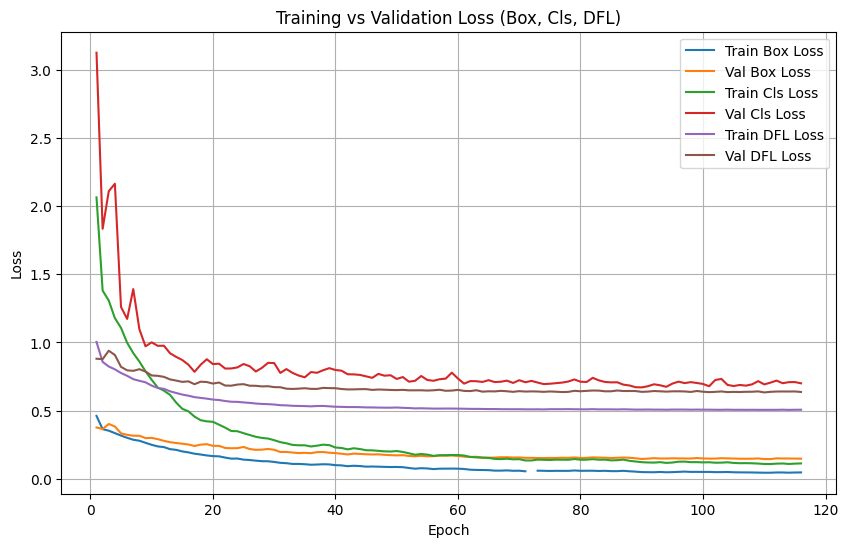

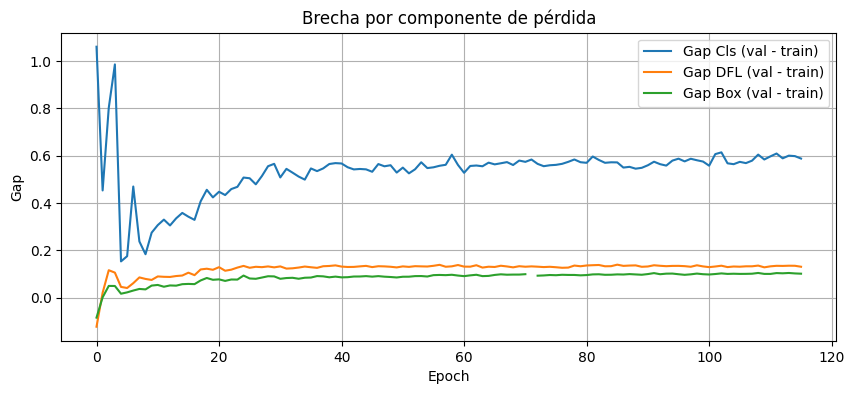

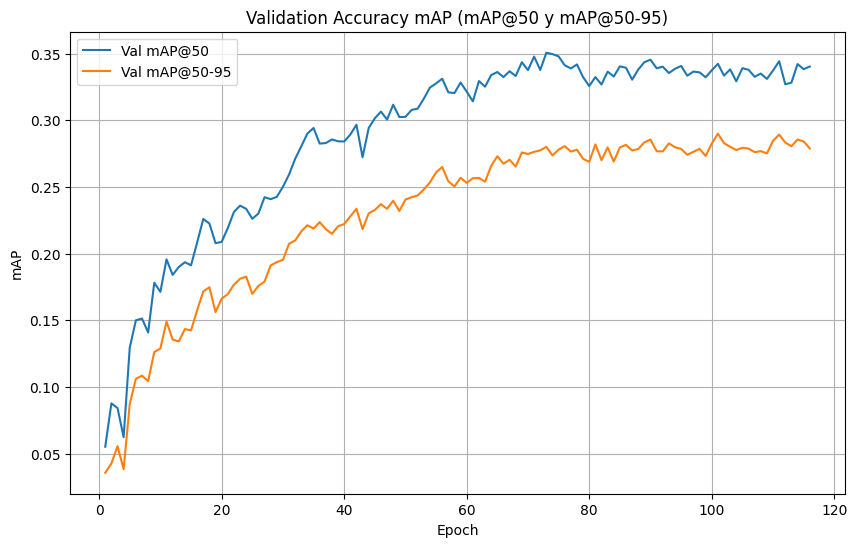

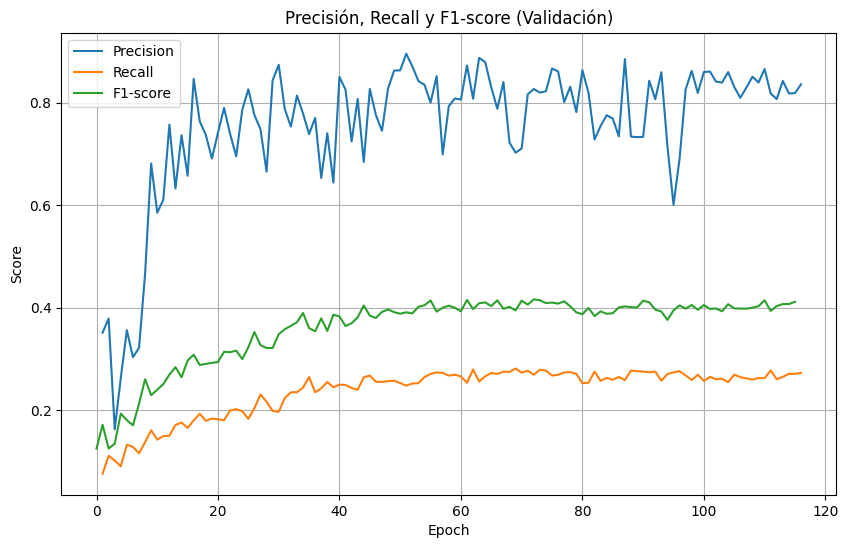

Final Metrics (last epoch):
Precision: 0.8357
Recall:    0.2728
F1-score:  0.4114


,Clase,Precision,Recall,F1,mAP50
0,link,0.762212,0.507472,0.609288,0.605361
1,button,0.797914,0.536878,0.641872,0.625322
2,input,0.946867,0.660135,0.77792,0.780846
3,select,clase sin métricas,clase sin métricas,clase sin métricas,clase sin métricas
4,textarea,0.904624,0.5,0.644033,0.680398
5,label,0.762323,0.355932,0.485283,0.457939
6,checkbox,clase sin métricas,clase sin métricas,clase sin métricas,clase sin métricas
7,radio,1.0,0.0,0.0,0.0
8,dropdown,0.852343,0.265823,0.405257,0.392467
9,slider,1.0,0.0,0.0,0.0


In [ ]:
visualizer_v8l.plot_loss() # Graficar Loss
visualizer_v8l.gap_entretrainyval() # Graficar Gap
visualizer_v8l.plot_map()  # Graficar mAP
visualizer_v8l.plot_precision_recall_f1() # Graficar Precision, Recall, F1
visualizer_v8l.print_final_metrics() # Mostrar métricas finales
#Metricas por Clase
df = visualizer_v8l.metrics_por_clase_tabla()   # Imprime Precision, Recall, F1 y mAP50 por clase
display(df)

### 6.3 Implementación de estrategia de mejora: Utilizar un Dataset Reducido (3 clases) / prototipo MVP

reducir el conjunto de clases y entrenar solo input, button, link para el primer prototipo.

- Ventaja: más datos por clase, menos falsos positivos y métricas más estables.

- Desventaja: Modificar el dataset actual, modificar archivos .txt de los labels y quitar clases que no se van a considerar


In [ ]:
#Modifica los labels del dataset original, reduciendo clases mapeadas en los archivos txt
#Solo deja las clases 0-link, 1-button, 2-input
datasetmanager.crear_datasetreducido()

2025-10-01 23:44:10,901 - YOLODatasetManager - INFO - Dataset copiado a /content/datasetreducido
2025-10-01 23:44:11,067 - YOLODatasetManager - INFO - Dataset reducido creado en /content/datasetreducido
2025-10-01 23:44:11,068 - YOLODatasetManager - INFO - Clases conservadas: {0: 'link', 1: 'button', 2: 'input'}


PosixPath('/content/datasetreducido/dataset_reducido.yaml')

Distribución: {'0': 15583, '1': 5101, '2': 354}


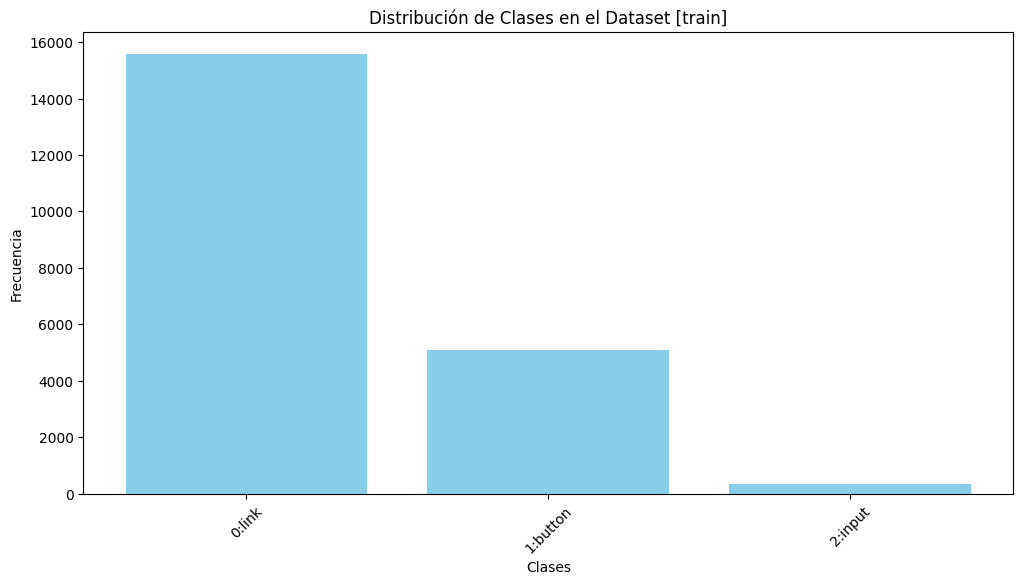

In [ ]:
datasetmanagerreducido = YOLODatasetManager("/content/datasetreducido")
counts = datasetmanagerreducido.compute_class_distribution("train")
print("Distribución:", counts)
datasetmanagerreducido.plot_distribution()

In [ ]:
#Entrenamiento de YoloV8 con el dataset reducido
from ultralytics import YOLO
datasetmanagerreducido.yaml_cambiar_carpeta(split="train",nuevaruta="train")
model = YOLO("yolov8l.pt")  # "Version Nano" o yolov8s.pt, yolov8m.pt según prefieras small, medium, etc.
carpeta_salida = "exp_l_data3" #carpeta donde se van a guardar los resultados del entrenamiento de YOLO y el modelo
model.train(data=datasetmanagerreducido.ruta_yaml,
    epochs=200, #epocas + early stopping (monitorear val mAP y parar si no mejora 10-15 ep).
    imgsz=640, #tamaño a los que se redimensionara la imagen de entrada
    batch=16,  #tamaño del batch (ajustarlo según Vram)
    name= carpeta_salida,   # nombre del run
    exist_ok=True,          # sobrescribe si ya existe
    project="/content/runs", # ruta de la carpeta runs
    augment=True,  # activa data augmentation
    cos_lr=True,   # scheduler coseno en lugar de lineal
    patience=15, # para no sobreentrenar
    # Learning rate y optimización
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0015,
    warmup_epochs=3.0,
    #warmup_momentum=0.8,
    #warmup_bias_lr=0.1,
    # Loss
    box=1.5,
    cls=0.35,
    dfl=1.0,
    # Data augmentation (seguro para UI)
    hsv_h=0.01,
    hsv_s=0.15,
    hsv_v=0.1,
    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,
    mixup=0.0
)

In [ ]:
visualizer_reduce = YOLOMetricasVisualizar(f"/content/runs/{carpeta_salida}/results.csv",
                                        f"/content/runs/{carpeta_salida}/weights/best.pt",datasetmanagerreducido.ruta_yaml)

## 6.4 Resúmen de lo ocurrido durante los diferentes entrenamientos

El desafío principal se centró en un **dataset fuertemente desbalanceado**:
* La **clase 'link' domina** ($\approx 75\%$ de los ejemplos).
* **Muchas clases tienen muy pocos o cero ejemplos** 📉.
* **Consecuencia**: Los modelos iniciales aprenden mal o ignoran por completo las clases minoritarias.

**El sobremuestreo (oversampling) de las clases minoritarias resultó impráctico.** Al muestrear las páginas que las contenían, se incrementó inevitablemente la frecuencia de las clases ya dominantes, provocando un **crecimiento excesivo y desbalanceado del dataset que invalidó el propósito inicial.**
Por esta razón el sobremuestreo fue descartado.

En el entrenamiento base se obtuvo lo siguiente:

| Métrica | Valor | Observación |
| :--- | :--- | :--- |
| **Precision** | Baja ($\approx 0.42$) | |
| **Recall** | **Muy bajo** ($\approx 0.14$) | Fallo grave en detectar clases minoritarias. |
| **F1-Score** | $\approx 0.21$ | |
| **Clases** | Nulas | **Muchas clases con métricas nulas** (no detectadas). |

Se detectó underfitting en las pruebas iniciales, lo que reforzó la necesidad de usar modelos más grandes (YOLOv8m/l) y ajustar hiperparámetros

Cambiar el tamaño del modelo tuvo un **impacto significativo en la precisión**.

- **Transición a modelos más grandes (YOLOv8m → YOLOv8l)**
- **Resultado**: Se observó un **incremento marcado en la Precision** general
- Aunque con YOLOv8l logró incrementar la precisión global, en las pruebas se evidenció que el resultado final presentaba mucho ruido en las predicciones. Esto se tradujo en numerosas detecciones falsas o poco consistentes en validación, lo cual indica que el aumento de capacidad del modelo no siempre se traduce en mejoras estables, especialmente cuando el dataset presenta clases desbalanceadas o etiquetas con ambigüedad.

El uso de un modelo más grande (YOLOv8l) debe complementarse con regularización y optimizaciones en hiperparámetros para evitar que el incremento en precisión venga acompañado de mayor cantidad de falsos positivos.

Una serie de optimizaciones en los hiperparámetros condujo a mejores resultados:

* **Parámetros Ajustados**:
    * Tasa de aprendizaje ($\text{lr}$)
    * $\text{weight\_decay}$
    * Pesos de pérdida ($\text{box}/\text{cls}/\text{dfl}$)
    * $\text{early\_stopping}$ (con el parámetro patience)
    * Se aplicó **data augmentation controlado (ajustes de color y ligeras transformaciones)**, lo que ayudó a reducir el sobreajuste y mejorar la generalización. Sin embargo, al ser un dataset de interfaces gráficas, un exceso de aumentos podía introducir ruido no realista.
* **Dataset Alternativo**:
    * se probó con un **dataset reducido de solo 3 clases**.


---

## 7️⃣ **Comparación antes/después de mejoras**

## 7.1 Comparativa de Experimentos YOLOv8

Se llevaron a cabo 8 pruebas o experimentos (Exp 1 a Exp 8) para optimizar el rendimiento de la detección de objetos con YOLOv8.

Para efectos de este informe, nos centraremos en el análisis de los experimentos más relevantes y representativos, manteniendo su numeración original para facilitar la referencia a las configuraciones específicas:

- **Exp 1 (Modelo base):** Como punto de partida sin optimizaciones.
- **Exp 6 y Exp 7:** Para demostrar la mejora incremental y la optimización fina de hiperparámetros y regularización sobre el dataset completo.
- **Exp 8:** Para evaluar el impacto de simplificar el problema a un dataset reducido de 3 clases.

Aunque se realizaron otras pruebas intermedias (Exp 2, 3, 4 y 5), las pruebas reportadas resumen de manera efectiva la trayectoria de optimización y las conclusiones clave obtenidas.

| Experimento | Configuración | Precision | Recall | F1 | Observación |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Exp 1** (baseline YOLOv8n) | Dataset original, default | **0.4194** | 0.1391 | 0.2089 | Desbalance y muchas clases sin aprendizaje. |
| **Exp 4** (YOLOv8m) | mismo dataset, modelo más grande | **0.6155** | 0.1969 | 0.2983 | Mejora clara en precision; recall aún bajo. |
| **Exp 6** (YOLOv8l; ajustes data augmentation sin afectar la geometría: lr, boxl, hsv) | lr=0.0025, box=2.0, hsv_s=0.15 | **0.7730** | 0.2632 | 0.3927 | Precision alta, gap en cls reducido. |
| **Exp 7** (tuning + reg) | lr=0.001, weight_decay=0.0015, box=1.5, cls=3.0, dfl=1.0, patience=15 | **0.8357** | 0.2728 | 0.4114 | Mejor precision global (casi 0.84); recall aún limitado. |
| **Exp 8** (dataset reducido: link/button/input) | mismo tuning sobre dataset 3-clases | **0.7454** | **0.5039** | **0.6013** | precision algo menor que Exp 7 pero **recall sube mucho** → **mejor F1**. |

A continuación se comparan los resultados o experimentos 1, 6 y 7, realizando las siguientes comparaciones:
- Pérdidas de Cajas (Box Loss) para los conjuntos de train y val
- Evolución de mAP50 durante el entrenamiento
- Comparación de Métricas finales

**Se seleccionó los Experimentos 1, 6 y 7 como una estrategia metodológica**, porque permite analizar la mejora del modelo de forma progresiva, aislando el impacto de las optimizaciones clave:

- **Exp 1 (Base):** Sirve como el punto de referencia indispensable. Representa el modelo inicial sin ajustes (YOLOv8n) sobre el dataset original. Es la base contra la cual se mide cualquier mejora.
- **Exp 6 (Primer Nivel de Ajustes):** Demuestra el efecto de las primeras optimizaciones importantes (cambios en el learning rate, pesos de pérdida y aumentación de datos). Este experimento muestra que las mejoras en el
tuning son efectivas para incrementar la Precision y el mAP.
- **Exp 7 (Tuning Refinado):** Representa el mejor modelo posible obtenido a través de una optimización exhaustiva de hiperparámetros y regularización (ajustes finos a lr, weight_decay, patience y pesos de pérdida).
- **El Experimento 8** se excluye de esta comparación principal porque utiliza una configuración de dataset fundamentalmente diferente a la de los Exps 1, 6 y 7.

## **7.2 Comparación de GAP en Box Loss (Exp 1, 6, 7)**

La gráfica compara la diferencia entre la pérdida de cajas en validación y la de entrenamiento (Gap=Val_Loss- Train_Loss) para los experimentos 1, 6 y 7.

- El Exp1 indica un claro problema de underfitting, donde el modelo YOLOV8n no tiene suficiente capacidad para aprender los patrones de localización ni siquiera en el training set.
- En los Ex 6 y 7, ambos tienen un gap consistente positivo, lo que indica q se corrigió el subajuste pero se introdujo sobreajuste (overfitting) más que nada en el exp 6
- El exp 7 logra un gap ligeramente más bajo. Los ajustes de regularización fueron ligeramente efectivos para mitigar el sobreajuste en comparación con el exp 6

La mejora del modelo (Exp 1 → Exp 6 → Exp 7) representa una transición de un modelo que subajusta y rinde mal en la localización (alta pérdida) a modelos que sobreajustan levemente pero tienen un rendimiento de localización mucho mejor (baja pérdida). El Exp 7 es el que mejor equilibra la baja pérdida de cajas con la generalización.









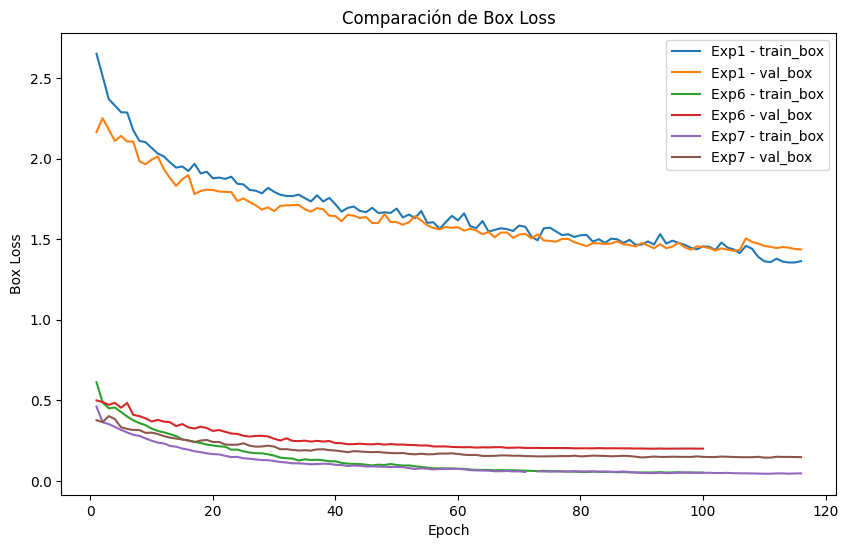

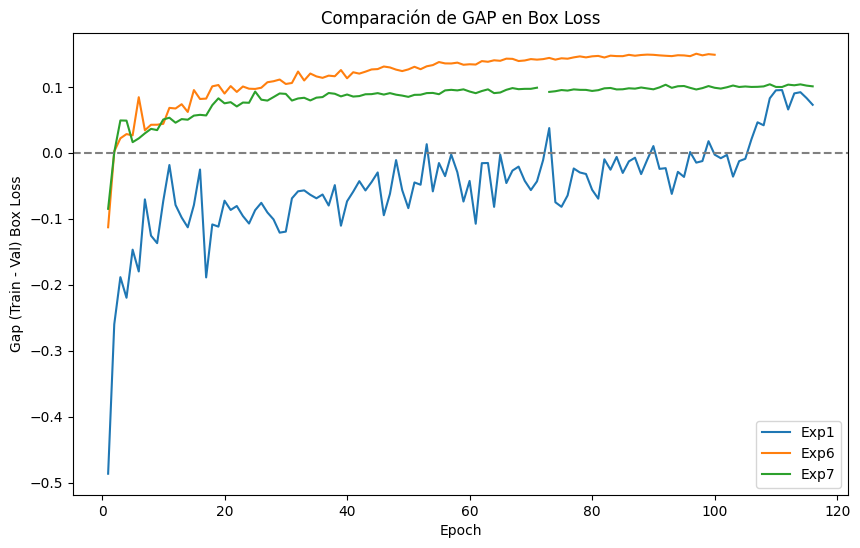

In [ ]:
visualizer_comparacion = YOLOMetricasVisualizar("/content/results_p1.csv",None,None)
visualizer_comparacion.comparar_resultados("/content/results_p1.csv","/content/results_p7.csv","/content/results_p6.csv","Exp1","Exp6","Exp7",graficoamostrar="boxloss")
visualizer_comparacion.comparar_resultados("/content/results_p1.csv","/content/results_p7.csv","/content/results_p6.csv","Exp1","Exp6","Exp7",graficoamostrar="gap")

## **7.3 Comparación de mAP50-95 durante el entrenamiento (Exp 1, 6, 7)**

El mAP50-95 (Mean Average Precision a través de diferentes umbrales de Intersection over Union) es una métrica crucial y muy rigurosa en tareas de detección de objetos, como las que estamos realizando con YOLOv8.

Indica la capacidad promedio del modelo para localizar objetos de manera precisa y clasificarlos correctamente, incluso bajo requisitos estrictos de solapamiento.

Un mAP50-95 alto no solo requiere que el modelo detecte los objetos (buen Recall) y los clasifique correctamente (buena Precision), sino que también exige una localización de caja excepcionalmente precisa.

- **Rendimiento Inicial (Exp 1):** El Exp 1 (modelo base) tiene un rendimiento de mAP50-95 significativamente inferior, por debajo de ≈0.15 durante todo el entrenamiento y estancándose temprano.
- **Mejora Drástica (Exp 6 y Exp 7):** Los Exp 6 y Exp 7 muestran una mejora masiva en el mAP50-95 en comparación con el modelo base. Ambos siguen una curva de aprendizaje muy similar, superando el mAP del Exp 1 desde las primeras épocas.
- **Ligeras Diferencias:** Aunque siguen trayectorias parecidas, el Exp 7 termina ligeramente por encima del Exp 6, alcanzando un valor final de mAP50-95 de aproximadamente 0.28

Aunque 0.28 es bajo en términos absolutos, es fundamental analizarlo relativamente en contexto con el modelo base. El experimento 7 casi triplicó el rendimiento del modelo base.

El valor de 0.28 no es un buen resultado absoluto, pero representa una mejora significativa y validada de la metodología de optimización. Indica que los futuros esfuerzos deben centrarse en resolver el problema del Recall (más datos de clases minoritarias, estrategias de remuestreo avanzadas)



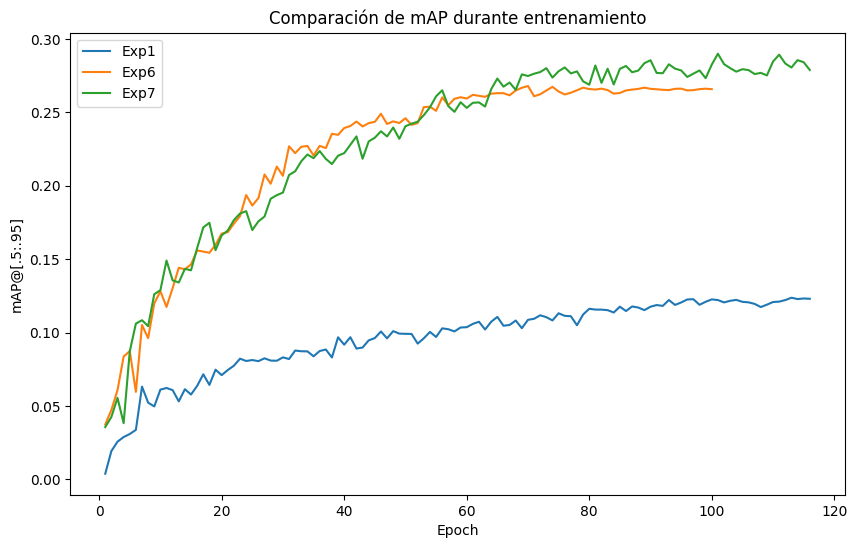

In [ ]:
visualizer_comparacion.comparar_resultados("/content/results_p1.csv","/content/results_p7.csv","/content/results_p6.csv","Exp1","Exp6","Exp7",graficoamostrar="map")

## **7.4 Comparación de métricas finales (Exp 1, 6, 7)**

La gráfica de barras compara el rendimiento final de los modelos en los Experimentos 1 (baseline), 6 (ajustes iniciales) y 7 (ajustes finos y regularización), mostrando una clara progresión en la efectividad.

El Experimento 7 es el claro ganador en todas las métricas de rendimiento y calidad de localización (mAP y Precision), validando la estrategia de optimización fina.

Sin embargo, el bajo valor de Recall en el Exp 7 (≈0.28) es el cuello de botella que limita los valores de mAP. Para lograr un rendimiento competitivo en un entorno de producción, los futuros esfuerzos deben centrarse en técnicas para incrementar el Recall sin sacrificar la alta Precision ya alcanzada.


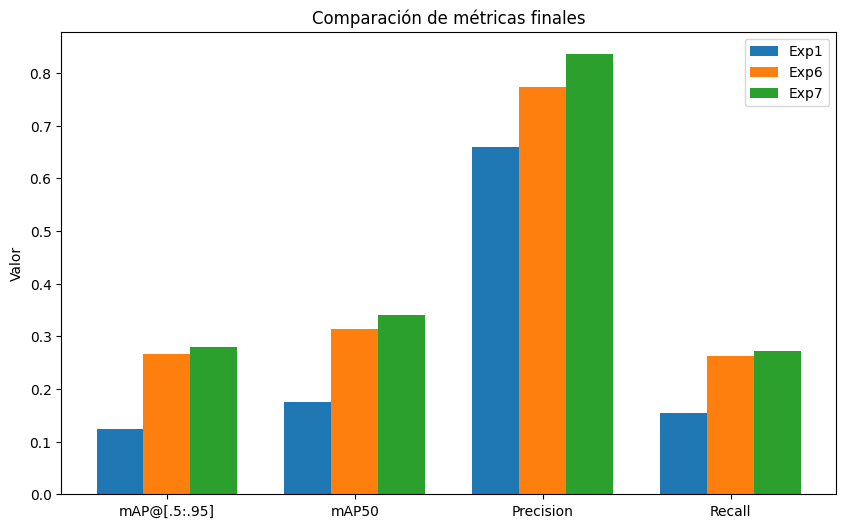

In [ ]:
visualizer_comparacion.comparar_resultados("/content/results_p1.csv","/content/results_p7.csv","/content/results_p6.csv","Exp1","Exp6","Exp7",graficoamostrar="barras")

## **7.5 Resultados del Experimento 8 - Con un Dataset Reducido (Solo clases 0-Link, 1-button, 2 input**

El Experimento 8 demuestra que el desbalance de clases y la complejidad del dataset original eran los principales factores limitantes del rendimiento:

- **Ganancia:** Al reducir la complejidad, el Recall mejora dramáticamente (de ≈0.27 a ≈0.50), resultando en el mejor F1-score.

- **Implicación:** Esto valida que para alcanzar un alto rendimiento, la estrategia debe centrarse en resolver el desbalance de clases del dataset original.

Las métricas finales confirman la efectividad de simplificar el problema:

- **Precision	0.7454**	Alta, aunque ligeramente menor que el Exp 7 (0.8357), indicando que el modelo es muy confiable en sus detecciones.
- **Recall	0.5039**	La mejora más importante. El Recall se duplicó con respecto al Exp 7 (≈0.27), lo que significa que al eliminar las clases minoritarias, el modelo es capaz de encontrar a la mitad de los objetos reales.
- **F1-score	0.6013**	Mejor métrica general. Este es el F1 más alto obtenido, reflejando el mejor balance entre Precision y Recall de todos los experimentos.

Evolución de mAP y Estabilidad

- **Rápida Convergencia:** Ambas métricas de mAP aumentan rápidamente desde la Época 10, lo que indica que el modelo (entrenado con menos clases y el tuning del Exp 7) aprende de manera eficiente la tarea de detección en este dataset simplificado.

- Ambas curvas se estabilizan después de la Época 40, lo que sugiere que la tasa de aprendizaje o la capacidad del modelo ya no pueden extraer más información valiosa del conjunto de validación en este punto. El mAP se mantiene estable hasta la Época 60.

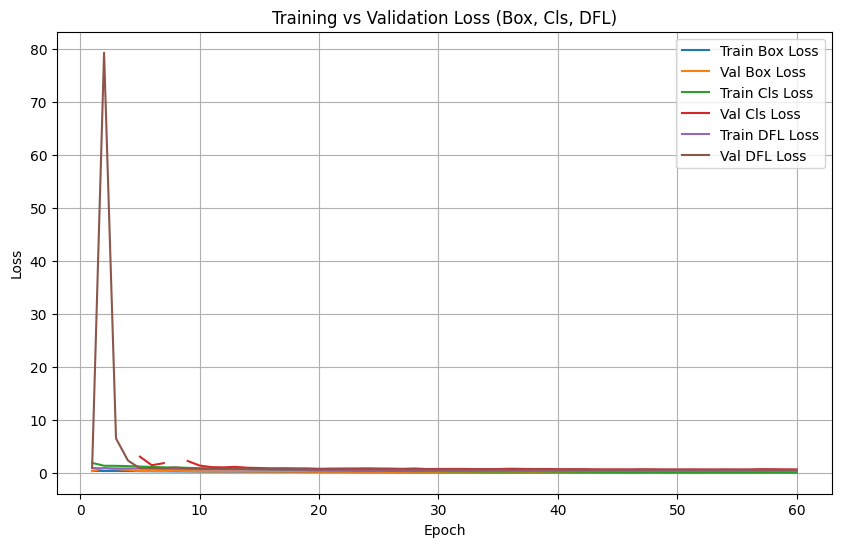

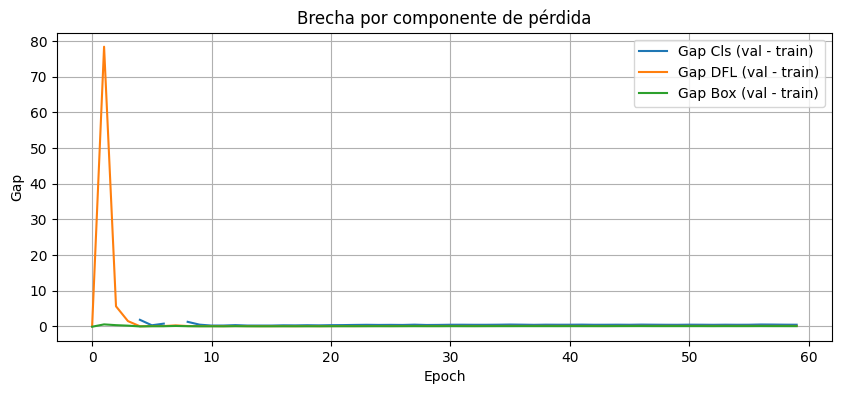

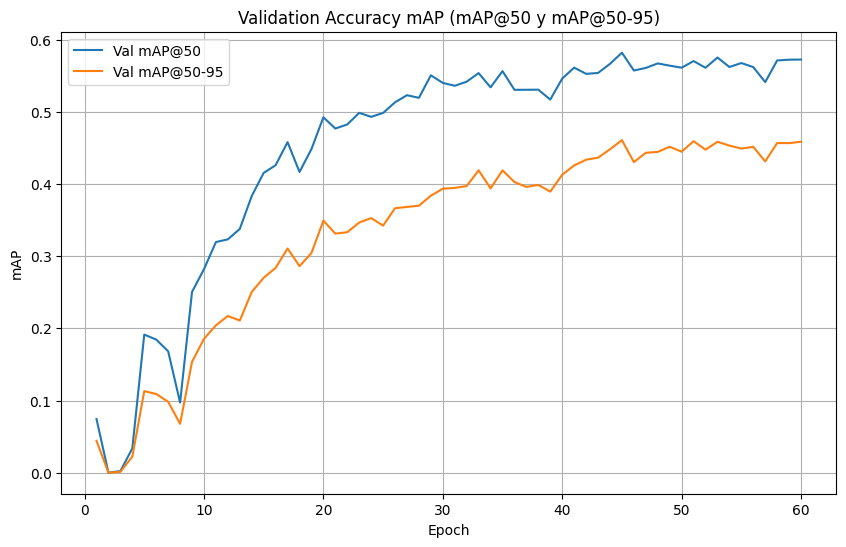

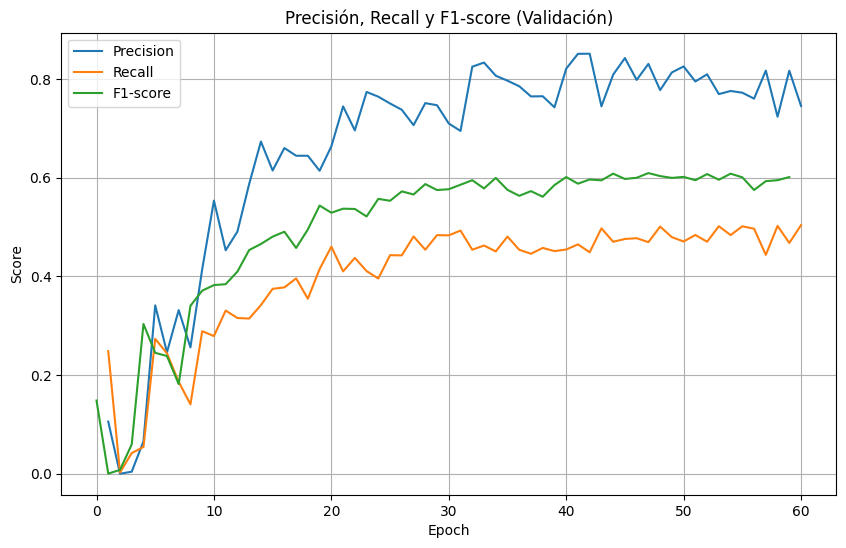

Final Metrics (last epoch):
Precision: 0.7454
Recall:    0.5039
F1-score:  0.6013


,Clase,Precision,Recall,F1,mAP50
0,link,0.811868,0.412606,0.547143,0.542749
1,button,0.861720,0.476844,0.613950,0.580182
2,input,0.851781,0.537037,0.658744,0.621938


In [ ]:
visualizer_reduce.plot_loss() # Graficar Loss
visualizer_reduce.gap_entretrainyval() # Graficar Gap
visualizer_reduce.plot_map()  # Graficar mAP
visualizer_reduce.plot_precision_recall_f1() # Graficar Precision, Recall, F1
visualizer_reduce.print_final_metrics() # Mostrar métricas finales
#Metricas por Clase
df = visualizer_reduce.metrics_por_clase_tabla()   # Imprime Precision, Recall, F1 y mAP50 por clase
display(df)

## 8️⃣ **Conclusiones y Reflexiones**

**Conclusiones principales**

- El principal limitador fue el desbalance y la escasez de datos para muchas clases, lo que provoca clasificaciones inestables y baja cobertura.

- **¿Qué funcionó?** combinación de:
  - modelo más grande (yolov8l)
  - reducción de LR
  - mayor regularización (weight_decay)
  - ajustar pesos de pérdida (box↓, cls↓, dfl↓)
  - early stopping (parámetro patiente) redujo la brecha de generalización y mejoró precision (Exp7).
  - Reducir el dataset a 3 clases

si se desea priorizar precisión (minimizar falsos positivos) usar configuración del Exp7. Pero considerar realizar un post-procesamiento al momento de utilizar el modelo y realizar la inferencia.

si se desea priorizar cobertura/recall (encontrar la mayoría de controles) optar por dataset reducido y el entrenamiento del exp 8. Este modelo sobre el dataset reducido a 3 clases mostró un buen equilibrio entre precisión y recall

